<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/classification_and_model_evaluation/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix

This fragment brings in the core tools needed to build, scale, and evaluate a binary/multiclass classification model.

NumPy & Pandas — numerical arrays and tabular data handling for clean preprocessing and analysis.

Matplotlib & Seaborn — plots and diagnostics (e.g., ROC curve, confusion matrix heatmap).

scikit-learn (sklearn):

datasets — convenient access to sample datasets for demos and experiments.

train_test_split — splits data into train/test sets for unbiased evaluation.

StandardScaler — standardizes features (zero mean, unit variance) to stabilize and improve model training.

LogisticRegression — a strong baseline classification model for linear decision boundaries.

Metrics:

accuracy_score — overall proportion of correct predictions.

roc_auc_score — discrimination quality across thresholds (area under ROC).

roc_curve — false-positive vs true-positive trade-off across thresholds.

classification_report — precision, recall, F1-score per class.

confusion_matrix — counts of true/false positives/negatives for detailed error analysis.

Together, these imports set up a complete classification pipeline: load data → split → scale → fit Logistic Regression → evaluate with accuracy, ROC-AUC, ROC curve, confusion matrix, and a full classification report.

In [3]:
X, y = datasets.load_wine(return_X_y=True)
feature_names = datasets.load_wine().feature_names

This code fragment loads the Wine dataset from Scikit-learn, separating it into feature data (X) and target labels (y) for classification analysis.
loads the dataset directly as NumPy arrays:

*   X – contains numerical values for the chemical features (such as alcohol, magnesium, and flavanoids).
*   y – represents the categorical class labels (0, 1, 2), corresponding to different grape cultivars.

This setup forms the foundation for data preprocessing, feature scaling, and model training, allowing the next steps to focus on classification tasks using logistic regression or other algorithms.

In [4]:
median_value = np.median(y)
y_class = (y > median_value).astype(int)

In this step, the original target variable from the Wine dataset, which initially contained three wine classes, is simplified into two categories to prepare the data for binary classification.

First, the median value of all class labels is calculated. Then, each sample is compared to this median: wines with class labels greater than the median are assigned to one group (class 1), while those equal to or below the median are assigned to another (class 0).

This transformation converts the dataset from a multiclass to a binary problem, making it easier to apply logistic regression and evaluate model performance in a clear “two-group” setup — distinguishing, for example, between wines of relatively higher and lower class categories.

In [5]:
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y_class

At this stage, all the data is organized into a single structured DataFrame for easier handling and analysis.

The numerical feature values obtained from the Wine dataset are combined with their corresponding column names to create a clear tabular structure. A new column named Target is then added, containing the binary class variable created earlier.

This results in a well-organized dataset where each row represents one wine sample, each column corresponds to a chemical feature, and the final column defines the class label. This format is ideal for further preprocessing, visualization, and model training, ensuring clarity and compatibility with analytical and machine learning tools.

In [6]:
print("First 7 rows of the dataset:")
print(df.head(7))

First 7 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   
5    14.20        1.76  2.45               15.2      112.0           3.27   
6    14.39        1.87  2.45               14.6       96.0           2.50   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24   

In this step, a short preview of the dataset is displayed to verify that it was created correctly.

The output shows the first seven rows of the table, allowing a quick inspection of the feature columns and the newly added Target variable. This helps confirm that all data has been loaded, labeled, and structured properly before moving on to preprocessing and modeling.

Such an early visual check is a common and important part of exploratory data analysis, ensuring that the dataset is clean, readable, and ready for further work.

In [7]:
print("\nDataset Summary:")
print(df.describe())


Dataset Summary:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359 

This step produces a statistical summary of the dataset to provide an overview of its main characteristics.

The summary includes key descriptive statistics for each feature — such as the count of observations, mean value, standard deviation, minimum and maximum values, and the quartiles. These indicators help to understand the general scale and spread of the data, detect possible outliers, and compare variability between features.

By reviewing this summary, the analyst can quickly assess data quality, identify potential anomalies, and decide whether further preprocessing steps such as normalization or outlier removal are necessary before modeling.

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64


This step checks the dataset for any missing or incomplete data.

The output lists each column along with the number of missing values it contains. This quick diagnostic helps verify whether the dataset is complete or if there are gaps that need to be handled — for example, by removing affected rows or replacing missing entries with estimated values.

Detecting missing data at this stage is an essential part of data validation, ensuring the reliability and consistency of the dataset before further statistical analysis or model training.

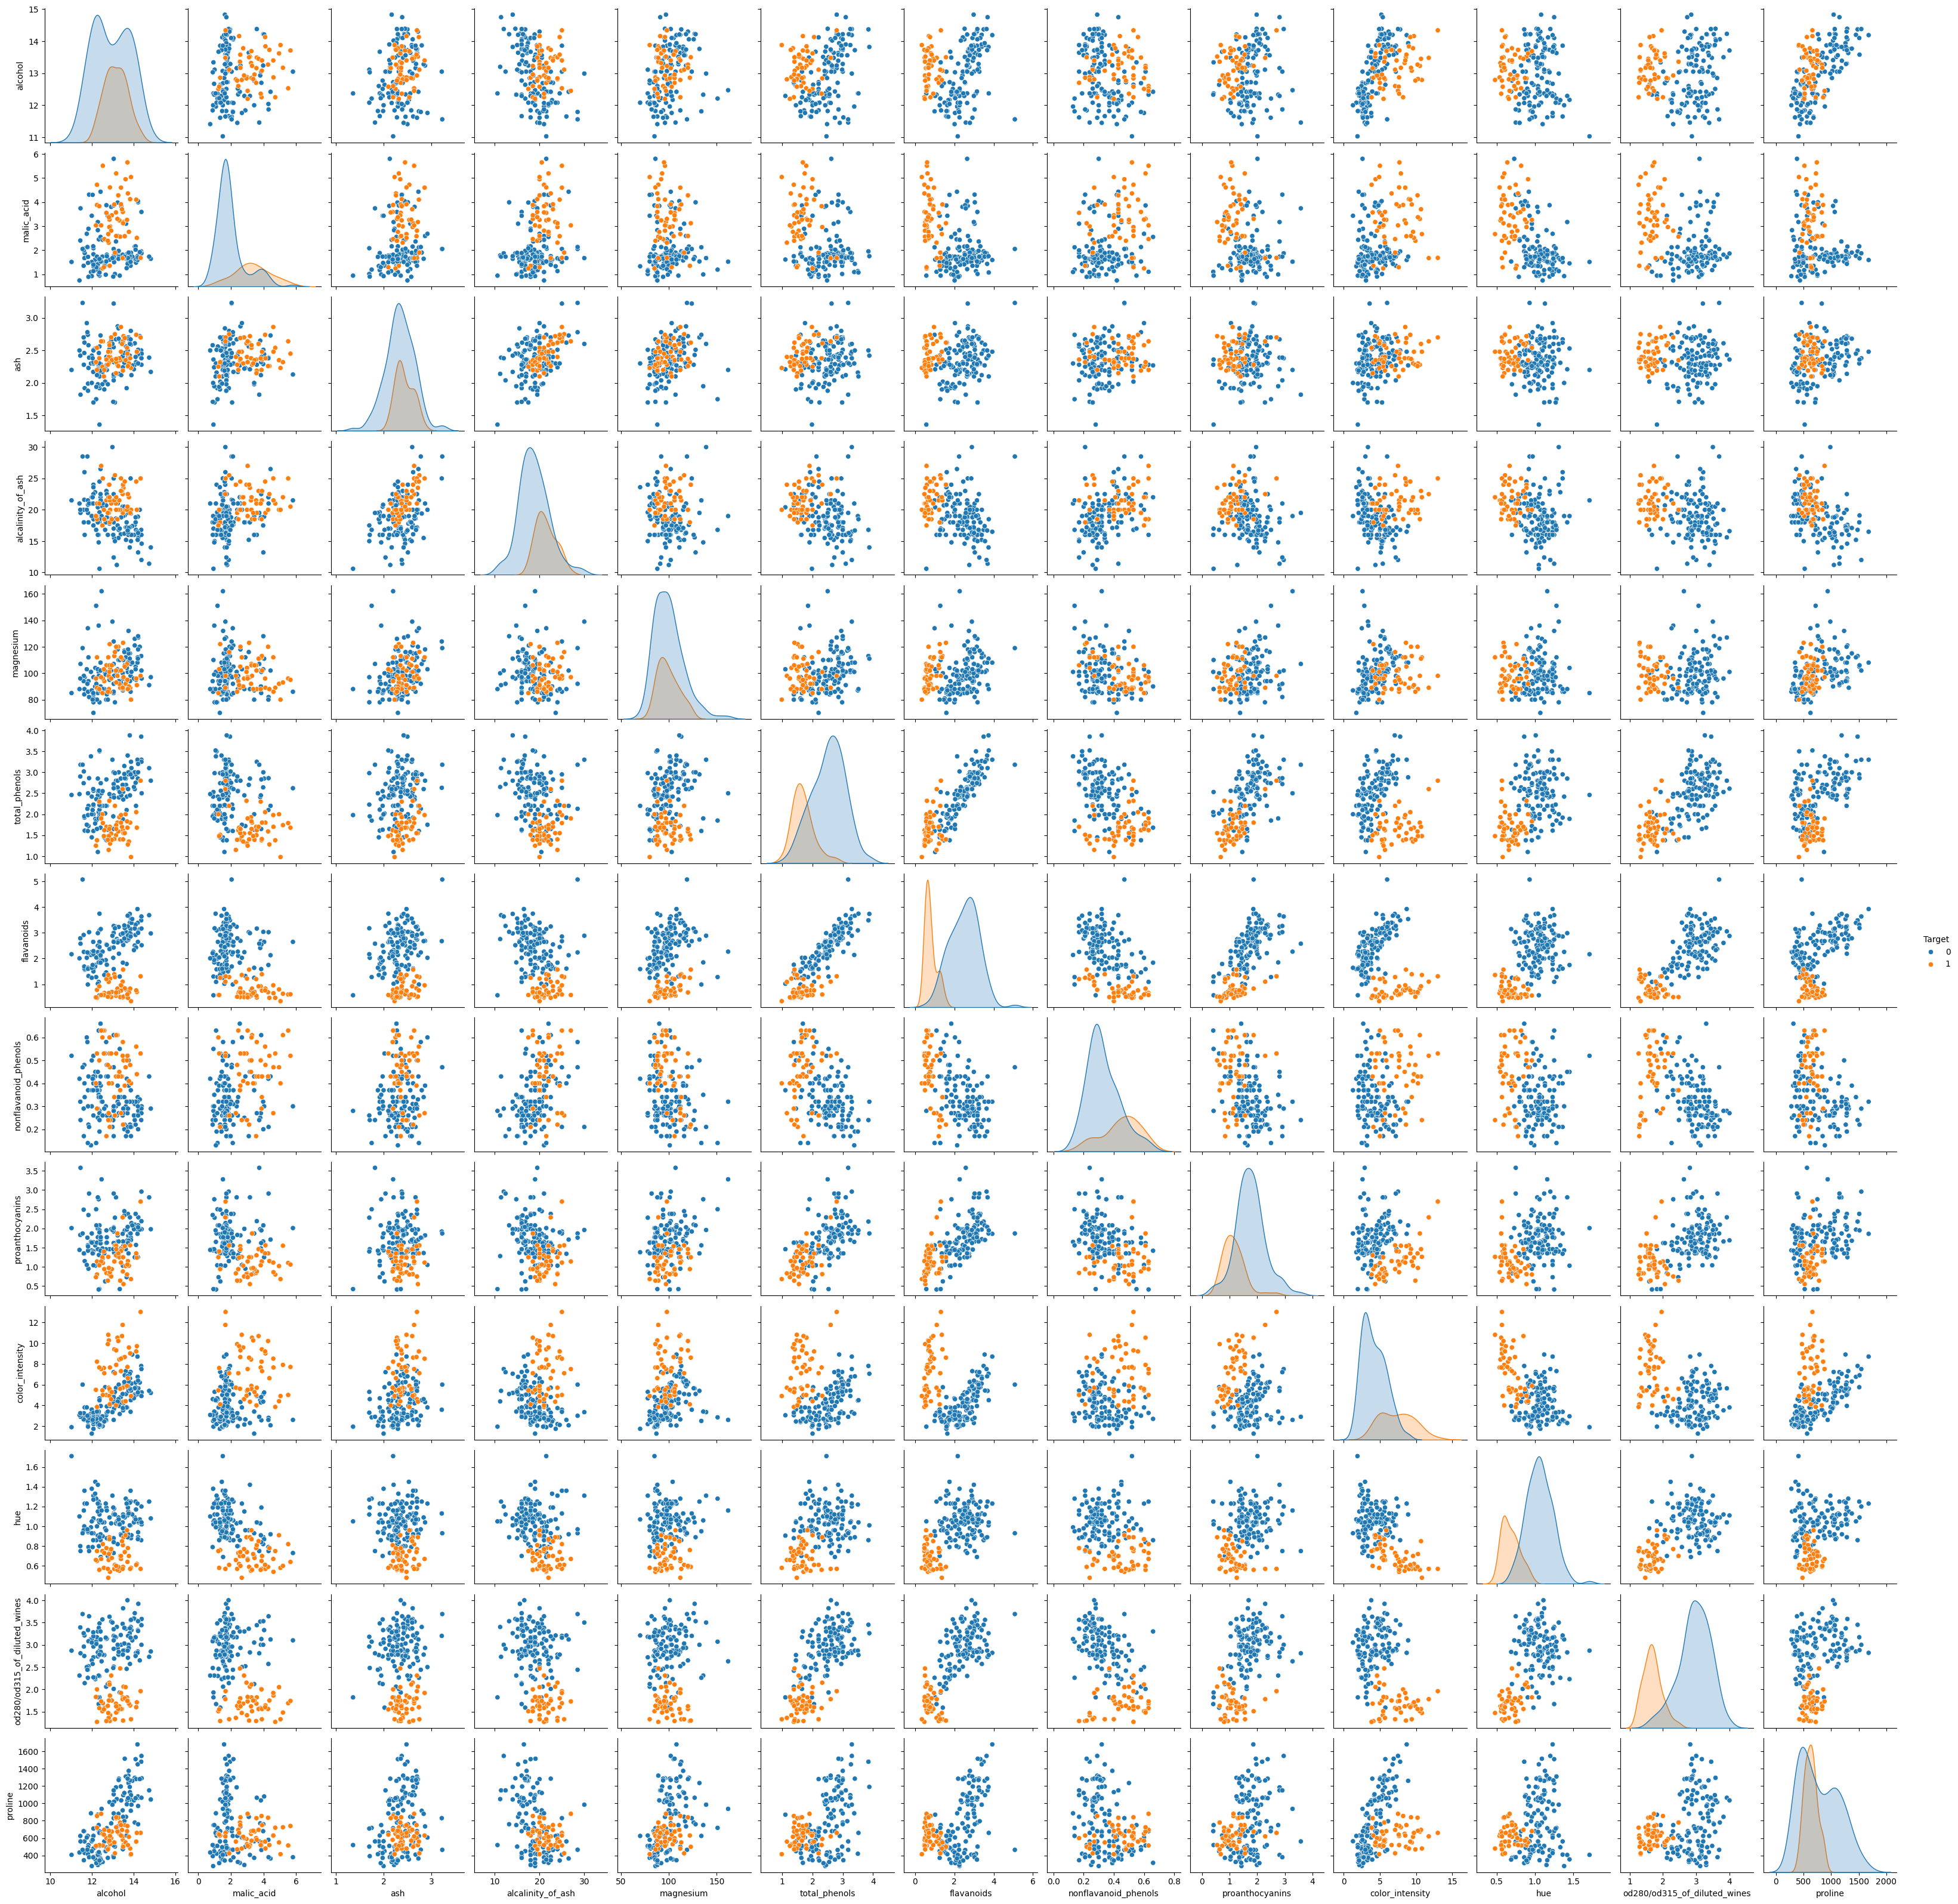

In [9]:
sns.pairplot(df, hue='Target', diag_kind='kde')
plt.show()

In this step, a pairplot is created to visually explore the relationships between all numerical features in the dataset.

Each scatterplot in the matrix shows how two features relate to each other, while the diagonal plots display the distribution of individual features using kernel density estimation. The parameter that defines color by the Target variable allows easy visual distinction between the two wine classes.

This type of visualization helps to identify patterns, potential correlations, or separability between classes — providing valuable intuition about which features might be most informative for the classification model.

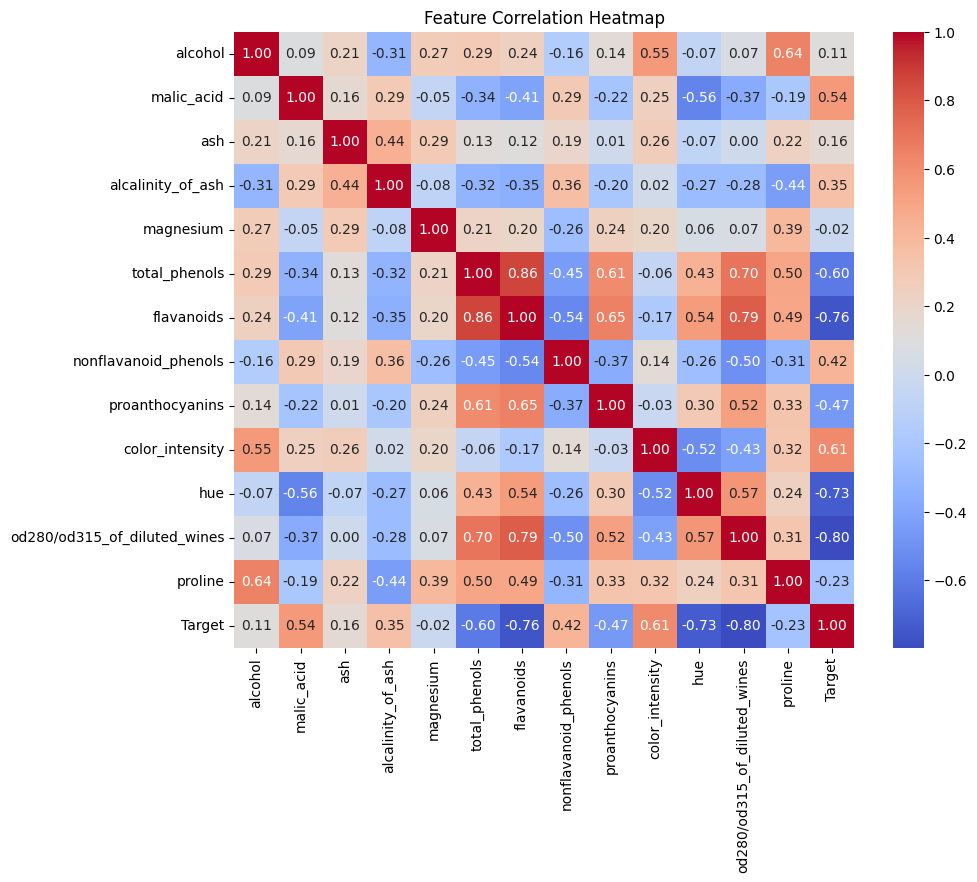

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In this step, a correlation heatmap is generated to visualize how strongly the numerical features in the dataset relate to one another.

Each cell in the heatmap represents the Pearson correlation coefficient between two features, with values ranging from −1 to +1. Positive values indicate that both variables increase together, while negative values show an inverse relationship. The closer the value is to ±1, the stronger the correlation.

The use of a coolwarm color palette helps clearly distinguish between positive and negative relationships, while the numeric annotations on each cell make it easy to interpret exact correlation values.

This visualization provides a quick overview of potential dependencies or redundancies among features, guiding further analysis and helping to identify which variables may be most relevant or require attention during model training.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.3, random_state=42)

In this step, the dataset is divided into two parts — a training set and a testing set — to enable proper model development and unbiased evaluation.

Seventy percent of the data is used for training, allowing the model to learn the underlying relationships between features and the target variable. The remaining thirty percent is kept aside as the testing set, which is used to assess how well the model performs on unseen data.

A fixed random state ensures that the split remains consistent each time the code is run, supporting reproducibility. This separation between training and testing data is essential for preventing overfitting and ensuring that the model’s accuracy reflects its true predictive ability.

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

At this stage, all numerical features are standardized to ensure that they share a common scale.

The StandardScaler adjusts the data so that each feature has a mean of zero and a standard deviation of one. This transformation prevents features with larger numerical ranges from dominating those with smaller values during model training.

The scaler is first fitted to the training data, where it learns the appropriate scaling parameters, and then the same transformation is applied to the testing data to maintain consistency.

Standardization is a crucial preprocessing step, especially for algorithms like logistic regression, as it improves numerical stability, ensures faster convergence, and helps the model treat all input variables equally.

In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In this step, a Logistic Regression model is created and trained using the standardized training data.

Logistic regression is a widely used classification algorithm that estimates the probability of each observation belonging to a particular class. It does this by fitting a linear equation to the data and applying a sigmoid function to produce outputs between 0 and 1.

During training, the model learns the relationship between the input features and the target classes by adjusting its internal coefficients to minimize prediction error. The result is a fitted model capable of predicting the likelihood that a given wine sample belongs to one of the two defined classes.

This trained model now serves as the foundation for evaluating classification performance and interpreting which chemical features most strongly influence the predicted wine category.

In [14]:
y_probs = model.predict_proba(X_test)[:, 1]

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


In this step, the trained logistic regression model is used to make predictions and evaluate its performance.

First, the model generates probability estimates for each sample in the test set, representing how likely each observation belongs to the positive class. Then, it produces discrete class predictions by assigning each sample to the most probable category.

The model’s effectiveness is assessed using the accuracy metric, which measures the proportion of correctly classified observations out of all predictions. A higher accuracy value indicates that the model correctly distinguishes between the two wine classes in most cases.

This stage provides a quick and straightforward evaluation of the model’s predictive ability, serving as the first step before performing deeper diagnostic checks such as ROC analysis or confusion matrix inspection.

In [15]:
roc_auc = roc_auc_score(y_test, y_probs)
print(f'ROC-AUC Score: {roc_auc:.4f}')

ROC-AUC Score: 1.0000


In this step, the model’s discriminative ability is evaluated using the ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) metric.

The ROC-AUC score measures how well the model distinguishes between the two classes across all possible classification thresholds. A value of 1.0 represents perfect classification, while 0.5 indicates no better performance than random guessing.

By using the predicted probabilities instead of binary predictions, this metric provides a more comprehensive evaluation of the model’s quality. A higher ROC-AUC score means the model is more effective at correctly ranking positive samples above negative ones — an important characteristic for reliable classification in real-world applications.

In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



This step provides a detailed summary of the model’s performance across both classes using the classification report.

The report includes several key metrics:

*   Precision – the proportion of correctly predicted positive samples out of all predicted positives, showing how reliable the positive predictions are.
*   Recall – the proportion of actual positive samples correctly identified by the model, reflecting its sensitivity.
*   F1-score – the harmonic mean of precision and recall, balancing both aspects for a single performance measure.
*   Support – the number of true instances for each class in the test set.

Together, these metrics give a clear picture of how well the logistic regression model performs in distinguishing between the two wine classes, highlighting both its strengths and areas for potential improvement.

Confusion Matrix:
[[40  0]
 [ 0 14]]


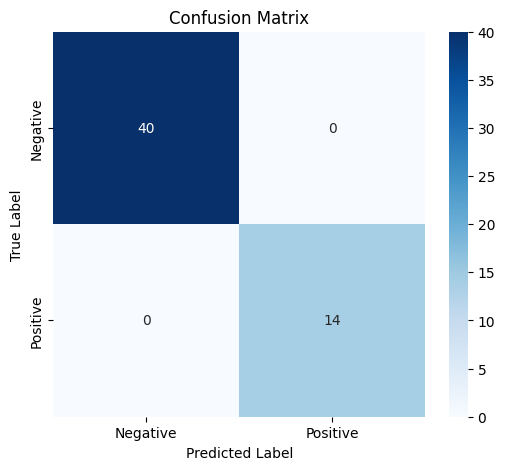

In [17]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# візуалізація матриці невідповідностей
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In this step, the model’s classification results are analyzed using a confusion matrix, which provides a detailed breakdown of prediction outcomes.

The matrix displays four key values:

*   True Positives (TP): correctly predicted positive cases.
*   True Negatives (TN): correctly predicted negative cases.
*   False Positives (FP): samples incorrectly classified as positive.
*   False Negatives (FN): samples incorrectly classified as negative.

By examining these values, it becomes possible to understand not only how many predictions were correct but also what types of errors the model made.

The matrix is then visualized as a heatmap for clarity, where darker colors indicate larger counts. Axis labels specify the true and predicted classes, and the title summarizes the plot’s purpose.

This visualization provides an intuitive overview of the classifier’s strengths and weaknesses, helping to assess whether the model tends to overpredict or underpredict one of the classes and guiding further optimization or threshold adjustment if needed.

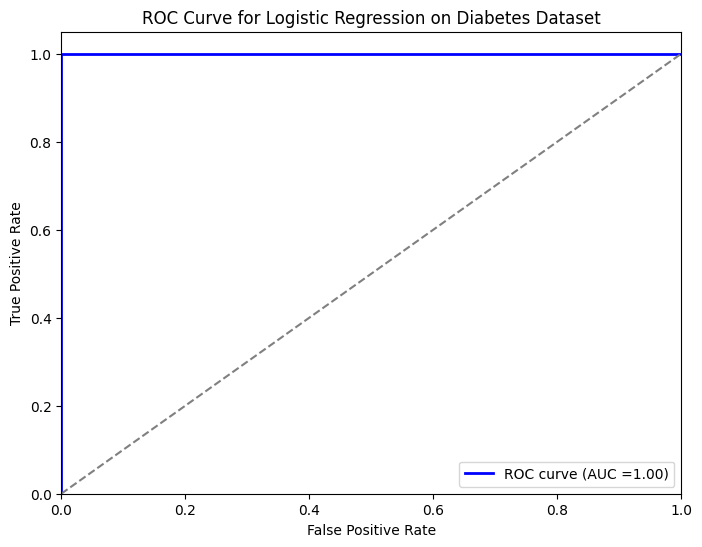

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC ={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression on Diabetes Dataset')
plt.legend(loc='lower right')
plt.show()

In this final step, the model’s ability to distinguish between the two classes is visualized through a Receiver Operating Characteristic (ROC) curve.

The ROC curve plots the True Positive Rate (sensitivity) on the y-axis against the False Positive Rate (1 – specificity) on the x-axis for various classification thresholds. Each point on the curve represents a different decision threshold, showing the trade-off between correctly detecting positive cases and avoiding false alarms.

A diagonal gray dashed line represents random guessing, serving as a baseline. The blue curve above it illustrates how well the logistic regression model performs — the farther the curve bends toward the upper-left corner, the better the model’s discriminative power.

The Area Under the Curve (AUC) value, displayed in the legend, quantifies this performance numerically:

*   A score close to 1.0 indicates excellent separation between classes.
*   A score near 0.5 suggests no meaningful discrimination.

This visualization provides a clear and intuitive summary of the model’s effectiveness, complementing previous metrics such as accuracy and the confusion matrix.